In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import time
import random
from torchinfo import summary

from data_handler import *
from trainer import *
from uncertainty import *
from linear_variational import *

# Check for GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

def set_random_seed(seed_value=42):
    # Python random seed
    random.seed(seed_value)
    
    # Numpy random seed
    np.random.seed(seed_value)
    
    # PyTorch seed
    torch.manual_seed(seed_value)
    
    # If using CUDA (GPU)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed_value)
        torch.cuda.manual_seed_all(seed_value)  # if using multi-GPU
        torch.backends.cudnn.deterministic = True  # For reproducibility
        torch.backends.cudnn.benchmark = False  # Disable auto-optimization for determinism

set_random_seed()

Using device: cuda


In [3]:
# Load data
train = pd.read_csv('TF_TS_train.csv')
test = pd.read_csv('TF_TS_test.csv')
valid = pd.read_csv('TF_TS_valid.csv')

# Interpolate the NaN values
train['TS'] = train['TS'].interpolate()
test['TS'] = test['TS'].interpolate()
valid['TS'] = valid['TS'].interpolate()

# Function to find rows with NaN values in a pandas DataFrame
def check_nans_in_dataframe(df, column_name, name):
    nan_rows = df[df[column_name].isna()]
    if not nan_rows.empty:
        print(f"Rows with NaN values in {name} dataset:")
        print(nan_rows)
    else:
        print(f"No NaN values in {name} dataset.")

# Check for NaN values in each dataset
check_nans_in_dataframe(train, 'TS', 'Train')
check_nans_in_dataframe(test, 'TS', 'Test')
check_nans_in_dataframe(valid, 'TS', 'Validation')

No NaN values in Train dataset.
No NaN values in Test dataset.
No NaN values in Validation dataset.


In [5]:
# Preprocess the data
scaler = MinMaxScaler(feature_range=(0, 1))
train_data = scaler.fit_transform(train)
test_data = scaler.transform(test)
valid_data = scaler.transform(valid)

# Create sequences
def create_sequences(data, lookback=10):
    X, y = [], []
    for i in range(lookback, len(data)):
        X.append(data[i-lookback:i])  # Use the last 'lookback' time steps for prediction
        y.append(data[i])  # The next time step is the target
    return np.array(X), np.array(y)

timesteps = 10
Xtrain, Ytrain = create_sequences(train_data, lookback=timesteps)
Xtest, Ytest = create_sequences(test_data, lookback=timesteps)
Xvalid, Yvalid = create_sequences(valid_data, lookback=timesteps)

# Convert to PyTorch tensors
Xtrain_tensor = torch.tensor(Xtrain, dtype=torch.float32).to(device)
Ytrain_tensor = torch.tensor(Ytrain, dtype=torch.float32).to(device)
Xtest_tensor = torch.tensor(Xtest, dtype=torch.float32).to(device)
Ytest_tensor = torch.tensor(Ytest, dtype=torch.float32).to(device)
Xvalid_tensor = torch.tensor(Xvalid, dtype=torch.float32).to(device)
Yvalid_tensor = torch.tensor(Yvalid, dtype=torch.float32).to(device)

print(
    f"""Xtrain, Ytrain: {Xtrain_tensor.shape}, {Ytrain_tensor.shape}
Xtest,   Ytest: {Xtrain_tensor.shape}, {Ytrain_tensor.shape}
Xvalid, Yvalid: {Xvalid_tensor.shape}, {Yvalid_tensor.shape}"""
)

Xtrain, Ytrain: torch.Size([340060, 10, 2]), torch.Size([340060, 2])
Xtest,   Ytest: torch.Size([340060, 10, 2]), torch.Size([340060, 2])
Xvalid, Yvalid: torch.Size([170025, 10, 2]), torch.Size([170025, 2])


In [7]:
class vLSTM(nn.Module):
    def __init__(self, in_features, hidden_size1, hidden_size2, hidden_size3, out_features, prior_mean=0, prior_variance=1.0, posterior_rho_init=-3.0, bias=True):
        super(vLSTM, self).__init__()

        # Define multiple LSTM layers
        self.lstm1 = nn.LSTM(in_features, hidden_size1, batch_first=True)

        self.lstm2 = nn.LSTM(hidden_size1, hidden_size2, batch_first=True)

        self.lstm3 = nn.LSTM(hidden_size2, hidden_size3, batch_first=True)
        
        self.fc = LinearReparameterization(
            in_features=hidden_size3,
            out_features=out_features,
            prior_mean=prior_mean,
            prior_variance=prior_variance,
            posterior_rho_init=posterior_rho_init,
            bias=bias
        )

    def forward(self, x, hidden_states=None):
        # LSTM1
        out, _ = self.lstm1(x, hidden_states)
    
        # LSTM2
        out, _ = self.lstm2(out, hidden_states)

        # LSTM3
        out, _ = self.lstm3(out, hidden_states)

        # Get the output for the **last time step** only: [batch_size, hidden_size]
        hidden_last_step = out[:, -1, :]  # Last time step

        # Pass through the final linear layer
        output, kl_fc = self.fc(hidden_last_step)
        kl_total = kl_fc

        # Return output and total KL divergence
        return output, kl_total

In [9]:
# Instantiate the model
batch_size = 256
learning_rate = 0.00018
num_epochs = 50
hidden1 = 48
hidden2 = 64
hidden3 = 32
criterion = nn.MSELoss()

model = vLSTM(in_features=2, hidden_size1=hidden1, hidden_size2=hidden2, hidden_size3=hidden3, out_features=2).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
summary(model, input_size=(batch_size, timesteps, 2), device=device)

Layer (type:depth-idx)                   Output Shape              Param #
vLSTM                                    [256, 2]                  --
├─LSTM: 1-1                              [256, 10, 48]             9,984
├─LSTM: 1-2                              [256, 10, 64]             29,184
├─LSTM: 1-3                              [256, 10, 32]             12,544
├─LinearReparameterization: 1-4          [256, 2]                  132
Total params: 51,844
Trainable params: 51,844
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 132.45
Input size (MB): 0.02
Forward/backward pass size (MB): 2.95
Params size (MB): 0.21
Estimated Total Size (MB): 3.18

In [11]:
# Load data into datasets followed by dataloaders
train_dataset = torch.utils.data.TensorDataset(Xtrain_tensor, Ytrain_tensor)
valid_dataset = torch.utils.data.TensorDataset(Xvalid_tensor, Yvalid_tensor)
test_dataset = torch.utils.data.TensorDataset(Xtest_tensor, Ytest_tensor)

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=batch_size)
valid_loader = torch.utils.data.DataLoader(valid_dataset, batch_size=batch_size)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=batch_size)

# Investigating the shape of data in train_loader
for batch_idx, (inputs, targets) in enumerate(train_loader):
    print(f"Batch {batch_idx+1}:")
    print(f"  Input shape: {inputs.shape}")
    print(f"  Target shape: {targets.shape}")
    
    # Break after inspecting the first batch
    break

Batch 1:
  Input shape: torch.Size([256, 10, 2])
  Target shape: torch.Size([256, 2])


In [13]:
# Timing
start = time.time()

# Train and validate the model
train_losses, val_losses = train_model(model, train_loader, valid_loader, num_epochs=num_epochs, reconstruction_loss_fn=criterion, optimizer=optimizer, kl_schedule=None, device=device)

end = time.time()
train_time = end - start
print(f"Training time on {torch.cuda.get_device_name()}: {train_time:.4f} seconds")

Epoch [1/50], Train Loss: 0.0191, Val Loss: 0.0150, KL Weight: 0.0001
Epoch [2/50], Train Loss: 0.0063, Val Loss: 0.0058, KL Weight: 0.0001
Epoch [3/50], Train Loss: 0.0036, Val Loss: 0.0048, KL Weight: 0.0001
Epoch [4/50], Train Loss: 0.0027, Val Loss: 0.0031, KL Weight: 0.0001
Epoch [5/50], Train Loss: 0.0025, Val Loss: 0.0038, KL Weight: 0.0001
Epoch [6/50], Train Loss: 0.0022, Val Loss: 0.0020, KL Weight: 0.0001
Epoch [7/50], Train Loss: 0.0019, Val Loss: 0.0020, KL Weight: 0.0001
Epoch [8/50], Train Loss: 0.0018, Val Loss: 0.0019, KL Weight: 0.0001
Epoch [9/50], Train Loss: 0.0016, Val Loss: 0.0018, KL Weight: 0.0001
Epoch [10/50], Train Loss: 0.0015, Val Loss: 0.0015, KL Weight: 0.0001
Epoch [11/50], Train Loss: 0.0014, Val Loss: 0.0019, KL Weight: 0.0001
Epoch [12/50], Train Loss: 0.0013, Val Loss: 0.0025, KL Weight: 0.0001
Epoch [13/50], Train Loss: 0.0013, Val Loss: 0.0015, KL Weight: 0.0001
Epoch [14/50], Train Loss: 0.0013, Val Loss: 0.0016, KL Weight: 0.0001
Epoch [15/50], 

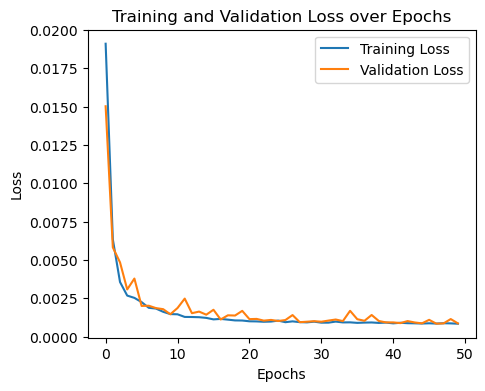

In [16]:
# Create the main plot
plt.figure(figsize=(5, 4))
plt.plot(train_losses, label="Training Loss")
plt.plot(val_losses, label="Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training and Validation Loss over Epochs")
plt.legend(loc='upper right')

plt.show()

In [18]:
# Function to make predictions multiple times to capture uncertainty
def predict_with_uncertainty(
    model,
    test_loader,
    n_samples=100,
    scaler_y=None,
    device=torch.device('cpu'),
    alpha=0.05
):
    """
    Runs MC sampling through `model` to estimate uncertainty,
    but without extra-process overhead.

    Returns:
      mean_preds: (N, K) array of predictive means
      true_vals:  (N, K) array of ground truths
      lower:      (N, K) lower bound at alpha/2 (default 2.5%)
      upper:      (N, K) upper bound at 1-alpha/2 (default 97.5%)
    """
    model.eval()
    all_preds = []
    all_trues = []

    with torch.no_grad():
        for inputs, targets in test_loader:
            inputs = inputs.to(device)
            targets = targets.to(device)

            # collect the true values
            all_trues.append(targets.cpu().numpy())

            # do n_samples forward passes _sequentially_
            batch_preds = []
            for _ in range(n_samples):
                outs, _ = model(inputs)
                batch_preds.append(outs.cpu().numpy())

            # shape (n_samples, batch, K)
            all_preds.append(np.stack(batch_preds, axis=0))

    # concatenate across batches → (n_samples, total_N, K)
    all_preds = np.concatenate(all_preds, axis=1)
    true_vals = np.concatenate(all_trues, axis=0)  # (total_N, K)

    # inverse scaling if needed
    if scaler_y is not None:
        true_vals = scaler_y.inverse_transform(true_vals)
        all_preds = np.array(
            [scaler_y.inverse_transform(p) for p in all_preds]
        )

    # now compute stats over the sample axis
    mean_preds = np.mean(all_preds, axis=0)   # (total_N, K)
    lower     = np.percentile(all_preds, 100 * (alpha/2),    axis=0)
    upper     = np.percentile(all_preds, 100 * (1-alpha/2), axis=0)

    return mean_preds, true_vals, lower, upper


n_samples = 250

# Timing
start = time.time()

# Predict on test data, sampling to obtain uncertainty estimation, plot for each output
mean_predictions, true_values, lower_ci, upper_ci = predict_with_uncertainty(model, test_loader, n_samples=n_samples, scaler_y=scaler, device=device)

end = time.time()
cpu_time = end - start
print(f"Prediction time: {cpu_time:.4f} seconds")

Prediction time: 301.8612 seconds


In [23]:
pred_determ = np.load('Ypred_rescaled.npy')

# Extract individual outputs for evaluation
pred_determ_ts, pred_determ_tf = pred_determ[:, 0], pred_determ[:, 1]

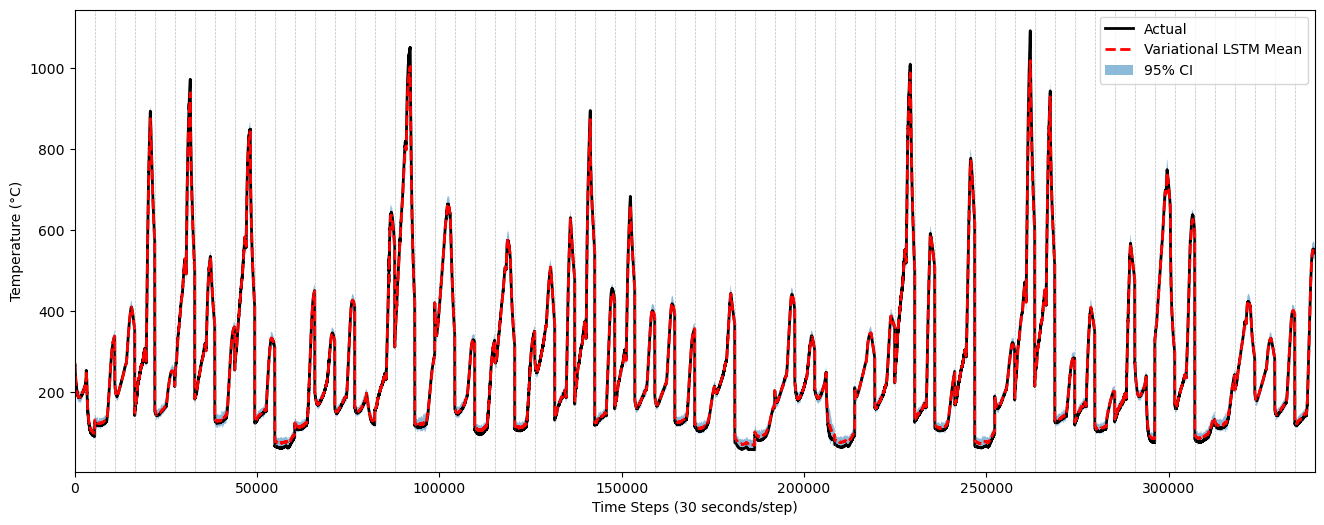

In [25]:
# Plot predictions vs actuals
plt.figure(figsize=(16, 6))
    
# Plot true values (ground truth)
plt.plot(true_values[:, 0], label='Actual', color='k', linewidth=2)

# plt.plot(pred_determ_ts, label="LSTM", color='b', linestyle='dashed')

# Plot predicted mean
plt.plot(mean_predictions[:, 0], label='Variational LSTM Mean', color='red', linestyle='--', linewidth=2)

# Plot confidence intervals (mean +/- confidence interval)
# plt.fill_between(
#     np.arange(mean_predictions.shape[0]),
#     mean_predictions[:, 0] - ci[:, 0],
#     mean_predictions[:, 0] + ci[:, 0],
#     color='red', alpha=0.2, label='Variational LSTM 95% Confidence Interval'
# )


N = len(mean_predictions)
x = np.arange(N)
plt.fill_between(
                x,
                lower_ci[:N, 0],
                upper_ci[:N, 0],
                alpha=0.5,
                label='95% CI'
            )

# Add vertical lines every 5485 time steps
for x in np.arange(5485, 340070, 5485):
    plt.axvline(x=x, color='gray', linestyle='--', linewidth=0.5, alpha=0.5)

plt.ylabel('Temperature (°C)')
plt.xlabel('Time Steps (30 seconds/step)')
plt.xlim(0, 340070)
plt.legend()
#plt.grid(True)
plt.show()

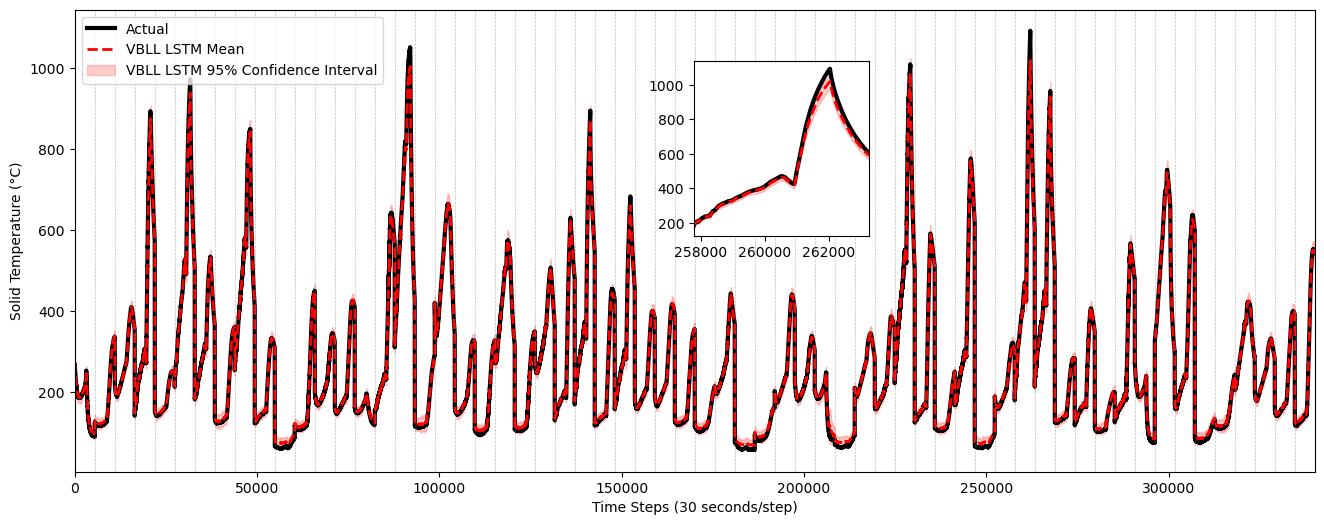

In [27]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

sensor_range_i = 257795
sensor_range_f = sensor_range_i + 5473

# Create the figure and main axes explicitly
fig, ax = plt.subplots(figsize=(16, 6))
x = np.arange(mean_predictions.shape[0])

# Plot true values (ground truth)
ax.plot(x, true_values[:, 0], label='Actual', color='k', linewidth=3)

# ax.plot(pred_determ_ts, label="LSTM", color='b')

# Plot predicted mean
ax.plot(x, mean_predictions[:, 0], label='VBLL LSTM Mean', color='red', linestyle='--', linewidth=2)

# Plot confidence intervals (mean +/- confidence interval)
ax.fill_between(
    x,
    mean_predictions[:, 0] - ci[:, 0],
    mean_predictions[:, 0] + ci[:, 0],
    color='red', alpha=0.2, label='VBLL LSTM 95% Confidence Interval'
)

# Add vertical lines every 5485 time steps in the main plot
for x_val in np.arange(5485, 340070, 5485):
    ax.axvline(x=x_val, color='gray', linestyle='--', linewidth=0.5, alpha=0.5)

ax.set_ylabel('Solid Temperature (°C)')
ax.set_xlabel('Time Steps (30 seconds/step)')
ax.set_xlim(0, 340070)
leg = ax.legend(loc="upper left")  # save the legend as an artist

# Create an inset axis using the main axis 'ax' and specify its position with bbox_to_anchor.
axins = inset_axes(ax,
                   width=1.75, height=1.75,
                   bbox_to_anchor=(0.52, 0.65, 0.1, 0.1),  # adjust as needed
                   bbox_transform=ax.transAxes,
                   loc='center')

# Create a mask for the desired x-range (sensor_range_i to sensor_range_f)
mask = (x >= sensor_range_i) & (x <= sensor_range_f)

# Re-plot the same data on the inset
axins.plot(x[mask], true_values[mask, 0], color='k', linewidth=3)
#axins.plot(x[mask], pred_determ_ts[mask], color='b')
axins.plot(x[mask], mean_predictions[mask, 0], color='red', linestyle='--', linewidth=2)
axins.fill_between(
    x[mask],
    mean_predictions[mask, 0] - ci[mask, 0],
    mean_predictions[mask, 0] + ci[mask, 0],
    color='red', alpha=0.2
)

# Set the x-limits of the inset to zoom into the desired range
axins.set_xlim(sensor_range_i, sensor_range_f)

# Save the figure.
# Include extra artists (like the inset and legend) in bbox_extra_artists so that they are considered in the layout.
fig.savefig('VBBL_TS.png', dpi=300, bbox_inches='tight', bbox_extra_artists=[axins, leg])
plt.show()

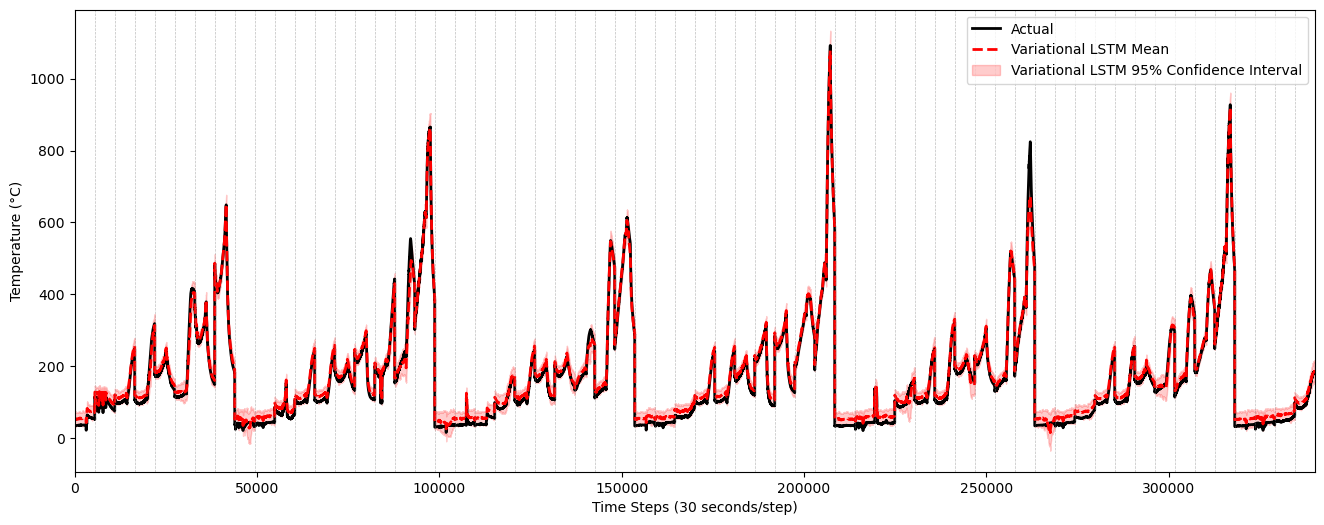

In [29]:
# Plot predictions vs actuals
plt.figure(figsize=(16, 6))
    
# Plot true values (ground truth)
plt.plot(true_values[:, 1], label='Actual', color='k', linewidth=2)

#plt.plot(pred_determ_tf, label="LSTM", color='b')

# Plot predicted mean
plt.plot(mean_predictions[:, 1], label='Variational LSTM Mean', color='red', linestyle='--', linewidth=2)

# Plot confidence intervals (mean +/- confidence interval)
plt.fill_between(
    np.arange(mean_predictions.shape[0]),
    mean_predictions[:, 1] - ci[:, 1],
    mean_predictions[:, 1] + ci[:, 1],
    color='red', alpha=0.2, label='Variational LSTM 95% Confidence Interval'
)

# Add vertical lines every 5485 time steps
for x in np.arange(5485, 340070, 5485):
    plt.axvline(x=x, color='gray', linestyle='--', linewidth=0.5, alpha=0.5)

plt.ylabel('Temperature (°C)')
plt.xlabel('Time Steps (30 seconds/step)')
plt.xlim(0, 340070)
plt.legend()
#plt.grid(True)
plt.show()

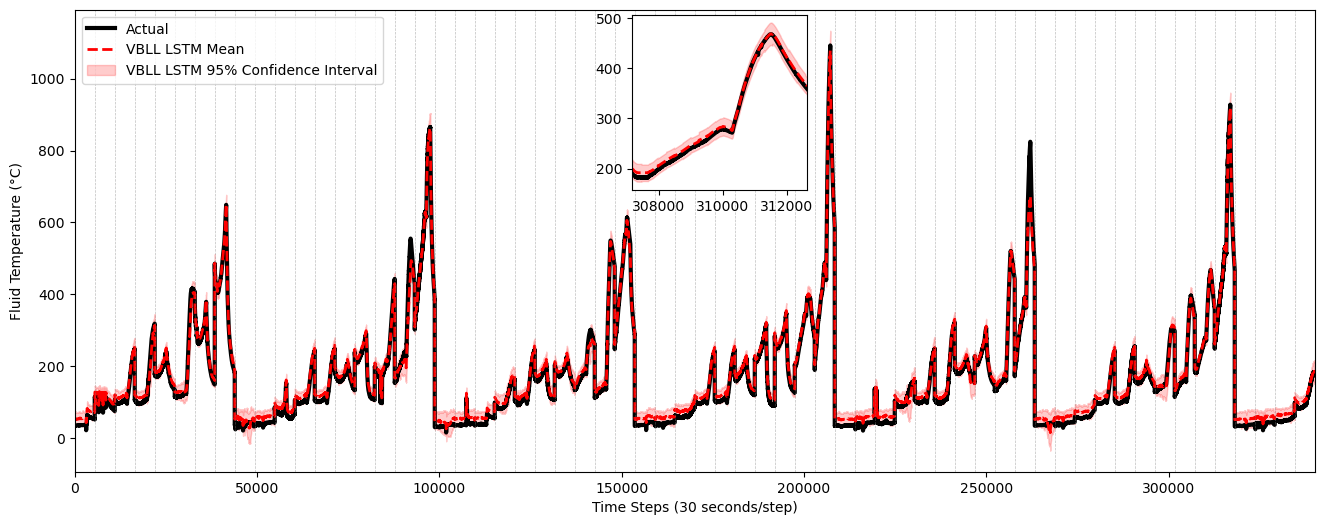

In [31]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

sensor_range_i = 307160
sensor_range_f = sensor_range_i + 5473

# Create the figure and main axes explicitly
fig, ax = plt.subplots(figsize=(16, 6))
x = np.arange(mean_predictions.shape[0])

# Plot true values (ground truth)
ax.plot(x, true_values[:, 1], label='Actual', color='k', linewidth=3)

#ax.plot(pred_determ_tf, label="LSTM", color='b')

# Plot predicted mean
ax.plot(x, mean_predictions[:, 1], label='VBLL LSTM Mean', color='red', linestyle='--', linewidth=2)

# Plot confidence intervals (mean +/- confidence interval)
ax.fill_between(
    x,
    mean_predictions[:, 1] - ci[:, 1],
    mean_predictions[:, 1] + ci[:, 1],
    color='red', alpha=0.2, label='VBLL LSTM 95% Confidence Interval'
)

# Add vertical lines every 5485 time steps in the main plot
for x_val in np.arange(5485, 340070, 5485):
    ax.axvline(x=x_val, color='gray', linestyle='--', linewidth=0.5, alpha=0.5)

ax.set_ylabel('Fluid Temperature (°C)')
ax.set_xlabel('Time Steps (30 seconds/step)')
ax.set_xlim(0, 340070)
leg = ax.legend(loc="upper left")  # save the legend as an artist

# Create an inset axis using the main axis 'ax' and specify its position with bbox_to_anchor.
axins = inset_axes(ax,
                   width=1.75, height=1.75,
                   bbox_to_anchor=(0.47, 0.75, 0.1, 0.1),  # adjust as needed
                   bbox_transform=ax.transAxes,
                   loc='center')

# Create a mask for the desired x-range (sensor_range_i to sensor_range_f)
mask = (x >= sensor_range_i) & (x <= sensor_range_f)

# Re-plot the same data on the inset
axins.plot(x[mask], true_values[mask, 1], color='k', linewidth=3)
#axins.plot(x[mask], pred_determ_tf[mask], color='b')
axins.plot(x[mask], mean_predictions[mask, 1], color='red', linestyle='--', linewidth=2)
axins.fill_between(
    x[mask],
    mean_predictions[mask, 1] - ci[mask, 1],
    mean_predictions[mask, 1] + ci[mask, 1],
    color='red', alpha=0.2
)

# Set the x-limits of the inset to zoom into the desired range
axins.set_xlim(sensor_range_i, sensor_range_f)

# Save the figure.
# Include extra artists (like the inset and legend) in bbox_extra_artists so that they are considered in the layout.
fig.savefig('VBBL_TF.png', dpi=300, bbox_inches='tight', bbox_extra_artists=[axins, leg])
plt.show()

In [26]:
calculate_and_display_metrics(true_values, mean_predictions)

Output 1:
  R² score: 0.9962
  MAE score: 5.2490
  RMSE score: 11.4196

Output 2:
  R² score: 0.9886
  MAE score: 10.9640
  RMSE score: 16.1311



In [33]:
import numpy as np

def compute_mape_per_output(true_values: np.ndarray, pred_values: np.ndarray) -> np.ndarray:
    """
    Compute MAPE for each output column:
      MAPE_j = 100 * mean(|true[:, j] - pred[:, j]| / |true[:, j]|)
    Ignores any zero entries in true to avoid division by zero.

    Args:
      true_values: shape (N, 2)
      pred_values: shape (N, 2)

    Returns:
      mape_per_output: shape (2,), with MAPE for each column
    """
    m, k = true_values.shape
    mape_per_output = np.zeros(k, dtype=float)

    for j in range(k):
        t_col = true_values[:, j]
        p_col = pred_values[:, j]
        nonzero_mask = t_col != 0
        if np.any(nonzero_mask):
            abs_perc_err = np.abs(t_col[nonzero_mask] - p_col[nonzero_mask]) / np.abs(t_col[nonzero_mask])
            mape_per_output[j] = 100.0 * np.mean(abs_perc_err)
        else:
            mape_per_output[j] = np.nan  # or some sentinel

    return mape_per_output



mape_TS, mape_TF = compute_mape_per_output(true_values, mean_predictions)
print(f"MAPE (TS) = {mape_TS:.4f}%")
print(f"MAPE (TF) = {mape_TF:.4f}%")

MAPE (TS) = 3.2448%
MAPE (TF) = 8.4715%
